In [13]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

Given a 2x2 binary sudoku, for each cell we can either choose 0 and 1 such that no column or row contains the same number.


![](binary_sudoku.png)

First, we have to prepare the search space (setting up the qubits + apply Hadamard gates to all of them)

Since there are 4 inputs, we need 4 input qubits.

In [14]:
input_qubits = QuantumRegister(4, name = 'i')

According to the rules, we have to make sure:

v0 /= v1

v0 /= v2

v1 /= v3

v2 /= v3

Therefore, we can initilize the rule as:

In [15]:
clauses = [[0,1],
           [0,2],
           [1,3],
           [2,3]]
clauses_qubits = QuantumRegister(4, name = 'c') # The value in the clause is the index of the qubit

One output qubit which represents if all the clauses are satisifed, and 4 classical bit to store the final answer:

In [16]:
output_qubit = QuantumRegister(1, name = 'out')
cbits = ClassicalRegister(4, name = 'cbits') 


Put the all together in a circuit and apply the Hadamard gates to all input qubits:

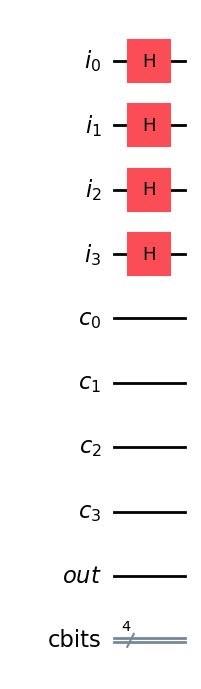

In [17]:
qc = QuantumCircuit(input_qubits, clauses_qubits, output_qubit, cbits)
qc.h(input_qubits)
qc.draw('mpl')

To check the clauses, we have to use XOR gate (It will not flip when the inputs are the same). We can implement that by applying two controlled-x gate.

In [18]:
def XOR(qc, a, b, output):
    qc.cx(a, output)
    qc.cx(b, output)

Now for the oracle, we need to create a checking circuit first.

In [19]:

def checking_circuit():
    i = 0
    for clause in clauses:
        XOR(qc, clause[0], clause[1], clauses_qubits[i])
        i += 1

    # Flip the output qubit if all clauses are flipped
    qc.mcx(clauses_qubits, output_qubit)


To turn the checking circuit to an oracle, we need to apply a concept called phase kickback. It means a controlled-x gate will affect its control qubit's phase if it's in superpositon. In addition, if we initialize the output qubit to state |->, the correct answer will be marked, followed this logic:

![](Explaination.png)

In [20]:
def oracle(qc, clauses_qubits, output_qubit):
    i = 0
    for clause in clauses:
        XOR(qc, clause[0], clause[1], clauses_qubits[i])
        i += 1

    # Flip the output qubit if all clauses are flipped
    qc.mcx(clauses_qubits, output_qubit)

    i = 0
    for clause in clauses:
        XOR(qc, clause[0], clause[1], clauses_qubits[i])
        i += 1
# oracle()
# qc.draw('mpl')

Next, we have to make the diffuser. It is responsible for amplifying the correct answer's probability. Fortunately, there's a general diffuser that would work for any problem. Essentially we only need to create the oracle to solve a problem.

In [21]:
def diffuser(nqubits):
    qc = QuantumCircuit(nqubits)
    # Apply transformation |s> -> |00..0> (H-gates)
    for qubit in range(nqubits):
        qc.h(qubit)
    # Apply transformation |00..0> -> |11..1> (X-gates)
    for qubit in range(nqubits):
        qc.x(qubit)
    # Do multi-controlled-Z gate
    qc.h(nqubits-1)
    qc.mcx(list(range(nqubits-1)), nqubits-1)  # multi-controlled-toffoli
    qc.h(nqubits-1)
    # Apply transformation |11..1> -> |00..0>
    for qubit in range(nqubits):
        qc.x(qubit)
    # Apply transformation |00..0> -> |s>
    for qubit in range(nqubits):
        qc.h(qubit)
    # We will return the diffuser as a gate
    U_s = qc.to_gate()
    U_s.name = "U$_s$"
    return U_s


To determine the number of iterations of oracle and diffuser, we can use the formula:

![](iteration_formula.png)

N: size of search space, m: number of answers

In our case, N = 4, m = 2 (it can also be 1), which would give 2.

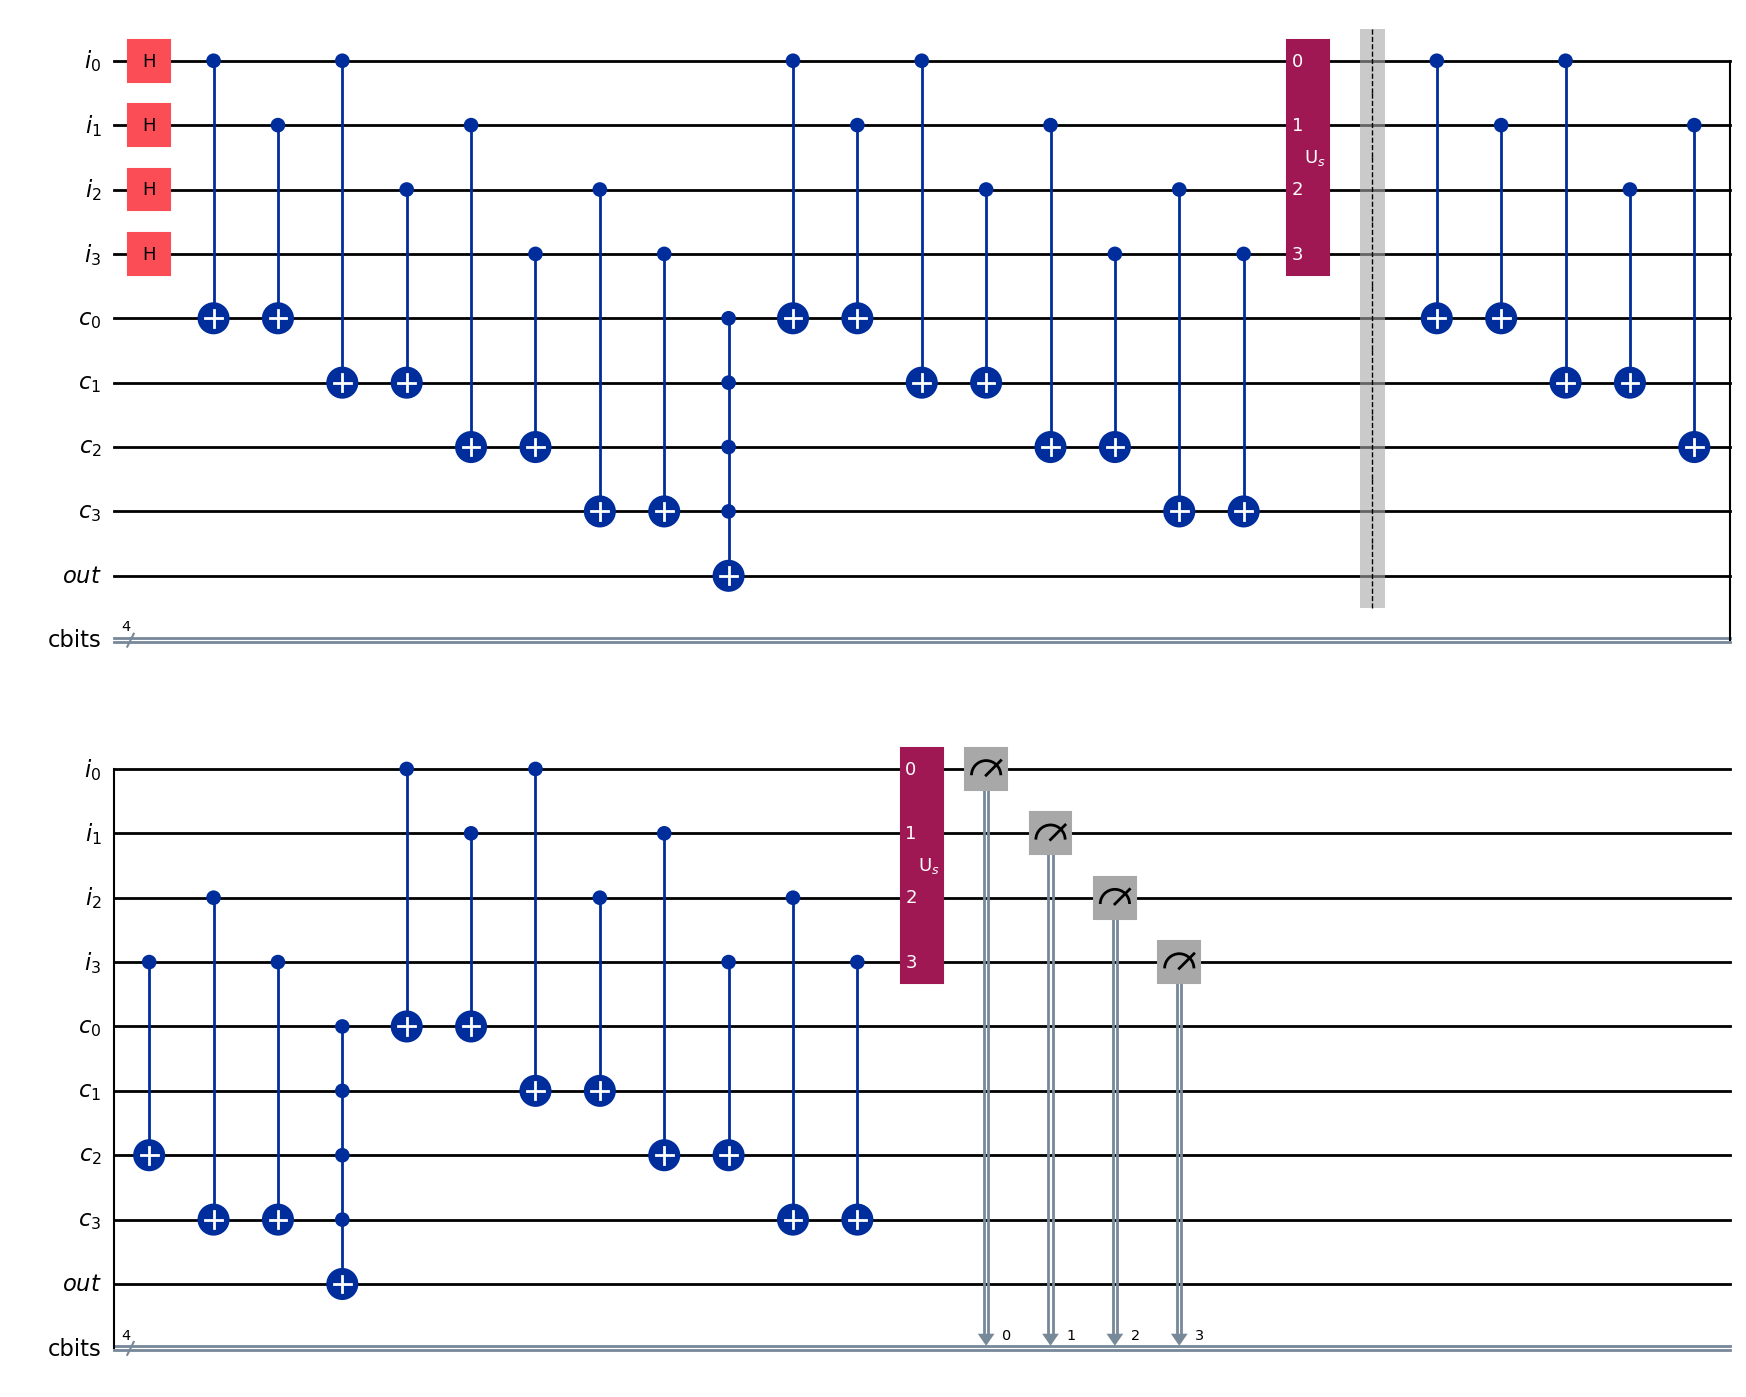

In [22]:
oracle(qc, clauses_qubits, output_qubit)
qc.append(diffuser(4), input_qubits)

qc.barrier() # for visual

oracle(qc, clauses_qubits, output_qubit)
qc.append(diffuser(4), input_qubits)

qc.measure(input_qubits, cbits)
qc.draw('mpl')

Full algorithm:

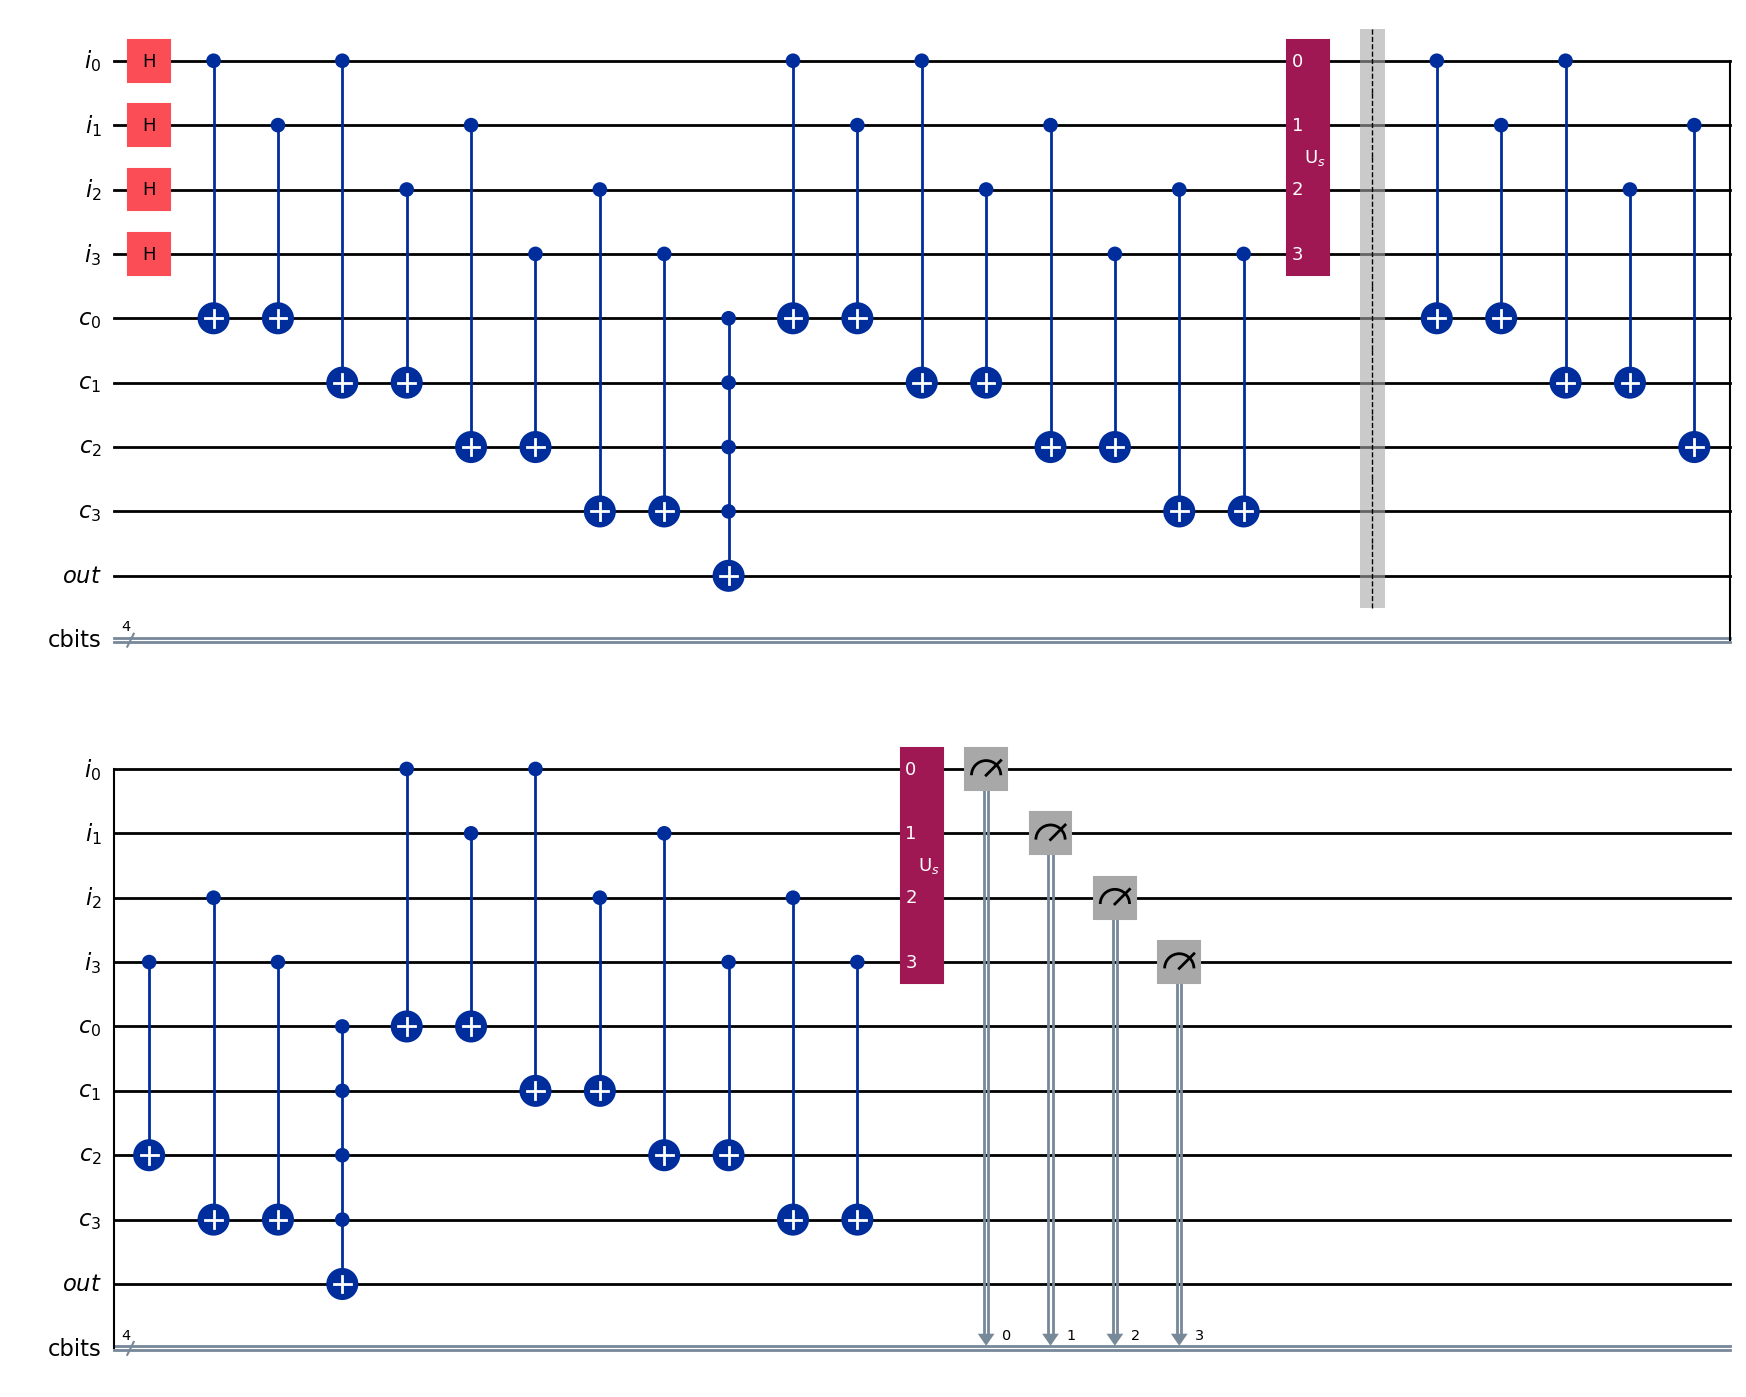

In [23]:
input_qubits = QuantumRegister(4, name = 'i')
clauses_qubits = QuantumRegister(4, name = 'c') # The value in the clause is the index of the qubit
output_qubit = QuantumRegister(1, name = 'out')
cbits = ClassicalRegister(4, name = 'cbits') 

qc = QuantumCircuit(input_qubits, clauses_qubits, output_qubit, cbits)
qc.h(input_qubits)

oracle(qc, clauses_qubits, output_qubit)
qc.append(diffuser(4), input_qubits)

qc.barrier() # for visual

oracle(qc, clauses_qubits, output_qubit)
qc.append(diffuser(4), input_qubits)


qc.measure(input_qubits, cbits)
qc.draw('mpl')


Test:

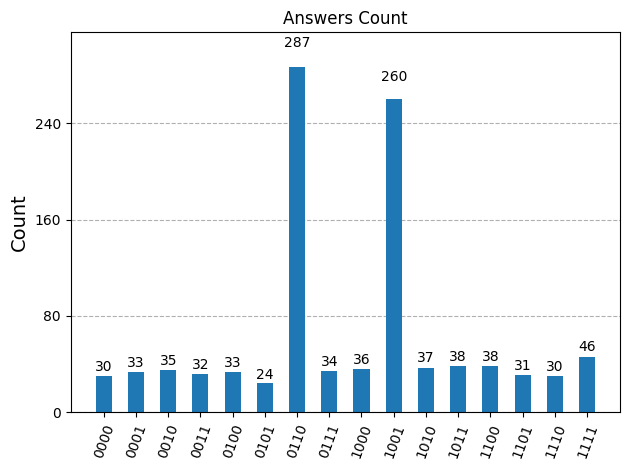

In [29]:
simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)

# Run and get counts
result = simulator.run(transpiled_qc).result()
counts = result.get_counts(transpiled_qc)
plot_histogram(counts, title='Answers Count')


0110 and 1001 are significantly more likely than the others, and they are indeed the answers to our problem.